# Desision Tree Demystified

## Titanic dataset



In [77]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn import tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
import warnings
warnings.filterwarnings("ignore")

In [23]:
sns.set_theme()

In [24]:
df1 = sns.load_dataset("titanic")

In [25]:
df1.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [26]:
df1.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [27]:
df2 = df1[['survived', 'pclass', 'sex', 'age', 'fare']]

In [28]:
df2.shape

(891, 5)

In [29]:
df2.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
fare,0


In [30]:
df2.describe()

,survived,pclass,age,fare
count,891.000000,891.000000,714.000000,891.000000
mean,0.383838,2.308642,29.699118,32.204208
std,0.486592,0.836071,14.526497,49.693429
min,0.000000,1.000000,0.420000,0.000000
25%,0.000000,2.000000,20.125000,7.910400
50%,0.000000,3.000000,28.000000,14.454200
75%,1.000000,3.000000,38.000000,31.000000
max,1.000000,3.000000,80.000000,512.329200


In [31]:
df3 = df2.copy()
df3.head()

,survived,pclass,sex,age,fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


In [32]:
df3.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
fare,0


In [39]:
df3.age.fillna(df3.age.mean(), inplace=True)
df3.age.isnull().sum()

np.int64(0)

In [41]:
df3.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
fare,0


In [42]:
# label encode sex column
le = LabelEncoder()
df3.sex = le.fit_transform(df3.sex)


In [44]:
df3.head()

,survived,pclass,sex,age,fare
0,0,3,1,22.0,7.2500
1,1,1,0,38.0,71.2833
2,1,3,0,26.0,7.9250
3,1,1,0,35.0,53.1000
4,0,3,1,35.0,8.0500


In [45]:
X = df3.drop('survived', axis=1)
y = df3['survived']

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [47]:
model = tree.DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [48]:
model.score(X_train, y_train)

0.9789325842696629

In [49]:
y_pred = model.predict(X_test)

In [50]:
accu_sc = accuracy_score(y_test, y_pred)
print(accu_sc)

0.7430167597765364


In [54]:
c_report = classification_report(y_test, y_pred)
print(c_report)

              precision    recall  f1-score   support

           0       0.79      0.77      0.78       105
           1       0.68      0.70      0.69        74

    accuracy                           0.74       179
   macro avg       0.74      0.74      0.74       179
weighted avg       0.74      0.74      0.74       179



In [58]:
import numpy as np
pclass_str, sex_str, age_str, fare_str = input("Enter 'pclass', 'sex', 'age', 'fare'").split()

# Convert string inputs to appropriate numeric types
pclass = int(pclass_str)
sex = int(sex_str)
age = float(age_str)
fare = float(fare_str)

print(f"pclass: {pclass}")
print(f"sex: {sex}")
print(f"age: {age}")
print(f"fare: {fare}")

# Create a NumPy array from the input values and reshape it for prediction
# The model expects a 2D array, even for a single sample (1 row, 4 columns for the features)
input_features = np.array([pclass, sex, age, fare]).reshape(1, -1)

final_pred = model.predict(input_features)
print(f"final_pred: {final_pred}")

Enter 'pclass', 'sex', 'age', 'fare'1 1 22 76
pclass: 1
sex: 1
age: 22.0
fare: 76.0
final_pred: [0]


# Random Forest Algorithm

In [59]:
from sklearn.datasets import load_digits
from sklearn.ensemble import RandomForestClassifier

In [63]:
digits = load_digits()

df = pd.DataFrame(digits.data, columns=digits.feature_names)
df["target"] = digits.target

df.head()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [64]:
df.shape

(1797, 65)

In [67]:
X = df.drop('target', axis=1)
y = df['target']
df.head(1)

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0


In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [71]:
model_rf = RandomForestClassifier(n_estimators=50)
model_rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=50)

In [72]:
model_rf.score(X_test, y_test)

0.9777777777777777

In [74]:
y_pred_rf = model_rf.predict(X_test)

In [75]:
accu_sc_rf = accuracy_score(y_test, y_pred_rf)
print(accu_sc_rf)

0.9777777777777777


In [76]:
creport_rf = classification_report(y_test, y_pred_rf)
print(creport_rf)

              precision    recall  f1-score   support

           0       1.00      0.97      0.98        33
           1       0.93      1.00      0.97        28
           2       1.00      1.00      1.00        33
           3       1.00      1.00      1.00        34
           4       0.98      1.00      0.99        46
           5       0.96      0.98      0.97        47
           6       0.97      0.97      0.97        35
           7       0.97      0.97      0.97        34
           8       1.00      0.90      0.95        30
           9       0.97      0.97      0.97        40

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



In [78]:
cm = confusion_matrix(y_test, y_pred_rf)
print(cm)

[[32  0  0  0  1  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  0 34  0  0  0  0  0  0]
 [ 0  0  0  0 46  0  0  0  0  0]
 [ 0  0  0  0  0 46  1  0  0  0]
 [ 0  0  0  0  0  1 34  0  0  0]
 [ 0  0  0  0  0  0  0 33  0  1]
 [ 0  2  0  0  0  1  0  0 27  0]
 [ 0  0  0  0  0  0  0  1  0 39]]


<Axes: >

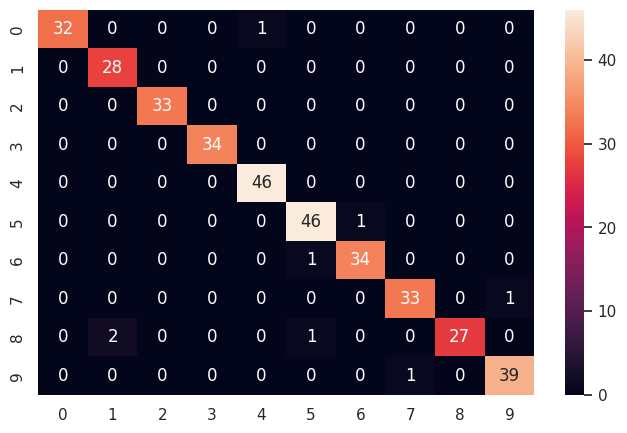

In [80]:
plt.figure(figsize=(8, 5))
sns.heatmap(cm, annot=True, fmt='d')

# Some Python Basics

In [36]:
x, y, z = input("Enter three numbers:").split()
print("Total number of students", x)
print("Total number of boys", y)
print("Total number of girls", z)

Enter three numbers:1 2 3
Total number of students 1
Total number of boys 2
Total number of girls 3


In [37]:
a = b = c = 100
print(a, b, c)

100 100 100


In [38]:
x, y, z = 12, 15.55, "Gopal"
print(x, y, z)
print(type(x), type(y), type(z))

12 15.55 Gopal
<class 'int'> <class 'float'> <class 'str'>
